In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [87]:

from sklearn.datasets import load_breast_cancer
X,y = load_breast_cancer(return_X_y=True, as_frame=True)

#this was my check to see in M or B was 0, the blurb on load_breast_cancer(found by hovering over it in VS code) 
# said there were 212 M ad 357 B. since there were 212 0's I know that 0 represents malignant and 1 represents benign
z = 0
w = 0
for i in y:
    if(i==0):
        z = z + 1
    else:
        w = w + 1

print("z:", z)
print("w:", w)



z: 212
w: 357


In [88]:

X_train, X_hold, y_train, y_hold = train_test_split(X, y, test_size=0.4, random_state=1, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_hold, y_hold, test_size=0.5, random_state=1, stratify=y_hold)

print(y_train.shape)
print(y_valid.shape)
print(y_test.shape)

(341,)
(114,)
(114,)


Logistic Regression

In [36]:
logreg_mod = model_2 = LogisticRegression(solver='lbfgs', penalty=None, max_iter=5000)
logreg_mod.fit(X_train, y_train)

print('Training Accuracy:  ', round(logreg_mod.score(X_train, y_train),4))
print('Validation Accuracy:', round(logreg_mod.score(X_test, y_test),4))

c:\Users\kaili\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Training Accuracy:   0.9912
Validation Accuracy: 0.9825


c:\Users\kaili\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Decision Tree

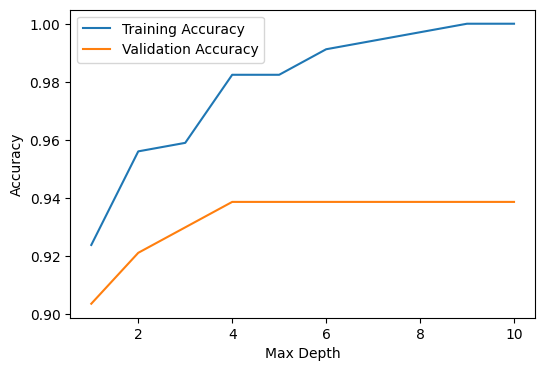

In [37]:
tr_acc = []
va_acc = []

depth_list = range(1,11)

for d in depth_list:
    temp_mod = DecisionTreeClassifier(max_depth=d, random_state=1)
    temp_mod.fit(X_train, y_train)
    tr_acc.append(temp_mod.score(X_train, y_train))
    va_acc.append(temp_mod.score(X_valid, y_valid))
    
plt.figure(figsize=([6,4]))
plt.plot(depth_list, tr_acc, label='Training Accuracy')
plt.plot(depth_list, va_acc, label='Validation Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [38]:
ix_best = np.argmax(va_acc)
best_md = depth_list[ix_best]
print('Optimal Value of max_depth:', best_md)

Optimal Value of max_depth: 4


In [39]:
tree_mod = DecisionTreeClassifier(max_depth=best_md, random_state=1)
tree_mod.fit(X_train, y_train)

print('Training Accuracy:  ', round(tree_mod.score(X_train, y_train),4))
print('Validation Accuracy:', round(tree_mod.score(X_valid, y_valid),4))

Training Accuracy:   0.9824
Validation Accuracy: 0.9386


Random Forest

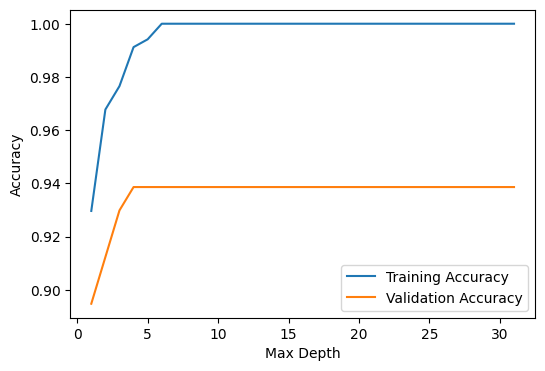

In [40]:
tr_acc = []
va_acc = []

depth_list = range(1,32)

for d in depth_list:
    forest_mod = RandomForestClassifier(max_depth=d, random_state=1)
    forest_mod.fit(X_train, y_train)
    tr_acc.append(forest_mod.score(X_train, y_train))
    va_acc.append(forest_mod.score(X_valid, y_valid))
    
plt.figure(figsize=([6,4]))
plt.plot(depth_list, tr_acc, label='Training Accuracy')
plt.plot(depth_list, va_acc, label='Validation Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [41]:
ix_best = np.argmax(va_acc)
best_md = depth_list[ix_best]
print('Optimal Value of max_depth:', best_md)

Optimal Value of max_depth: 4


In [42]:
forest_mod = RandomForestClassifier(n_estimators=500, max_depth=4, random_state=1)
forest_mod.fit(X_train, y_train)

print('Training Accuracy:  ', round(forest_mod.score(X_train, y_train),4))
print('Validation Accuracy:', round(forest_mod.score(X_valid, y_valid),4))

Training Accuracy:   0.9853
Validation Accuracy: 0.9298


Scoring Final Model

In [43]:
print('Test Set Accuracy:', round(logreg_mod.score(X_test, y_test),4))

Test Set Accuracy: 0.9825


Confusion Matrix - Logistic Regression

In [96]:
log_y_pred = logreg_mod.predict(X_test)
log_cm = confusion_matrix(y_test,log_y_pred)
#print(log_y_pred)
print(log_cm)
pd.DataFrame(log_cm, index=['Actual M', 'Actual B'], 
            columns=['Pred M', 'Pred B'], )

[[41  1]
 [ 1 71]]


,Pred M,Pred B
Actual M,41,1
Actual B,1,71


In [89]:
logreg_1_precision = np.sum((log_y_pred == 1) & (y_test == 1) ) / np.sum(log_y_pred == 1)
logreg_1_recall = np.sum((log_y_pred == 1) & (y_test == 1) ) / np.sum(y_test == 1)

print('Benign Precision:', round(logreg_1_precision,4))
print('Benign Recall:   ', round(logreg_1_recall,4))
print("\n")

logreg_0_precision = np.sum((log_y_pred == 0) & (y_test == 0) ) / np.sum(log_y_pred == 0)
logreg_0_recall = np.sum((log_y_pred == 0) & (y_test == 0) ) / np.sum(y_test == 0)

print('Malignant Precision:', round(logreg_0_precision,4))
print('Malignant Recall:   ', round(logreg_0_recall,4))
print("\n")

print(classification_report(y_test, log_y_pred, digits=4))

Benign Precision: 0.9861
Benign Recall:    0.9861


Malignant Precision: 0.9762
Malignant Recall:    0.9762


              precision    recall  f1-score   support

           0     0.9762    0.9762    0.9762        42
           1     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



Confusion Matrix - Decision Tree

In [97]:
tree_y_pred = tree_mod.predict(X_test)
tree_cm = confusion_matrix(y_test,tree_y_pred)
#print(tree_y_pred)
print(tree_cm)
pd.DataFrame(tree_cm, index=['Actual M', 'Actual B'], 
            columns=['Pred M', 'Pred B'], )

[[38  4]
 [ 0 72]]


,Pred M,Pred B
Actual M,38,4
Actual B,0,72


In [90]:
tree_1_precision = np.sum((tree_y_pred == 1) & (y_test == 1) ) / np.sum(tree_y_pred == 1)
tree_1_recall = np.sum((tree_y_pred == 1) & (y_test == 1) ) / np.sum(y_test == 1)

print('Benign Precision:', round(tree_1_precision,4))
print('Benign Recall:   ', round(tree_1_recall,4))
print("\n")

tree_0_precision = np.sum((tree_y_pred == 0) & (y_test == 0) ) / np.sum(tree_y_pred == 0)
tree_0_recall = np.sum((tree_y_pred == 0) & (y_test == 0) ) / np.sum(y_test == 0)

print('Malignant Precision:', round(tree_0_precision,4))
print('Malignant Recall:   ', round(tree_0_recall,4))
print("\n")

print(classification_report(y_test, tree_y_pred, digits=4))

Benign Precision: 0.9474
Benign Recall:    1.0


Malignant Precision: 1.0
Malignant Recall:    0.9048


              precision    recall  f1-score   support

           0     1.0000    0.9048    0.9500        42
           1     0.9474    1.0000    0.9730        72

    accuracy                         0.9649       114
   macro avg     0.9737    0.9524    0.9615       114
weighted avg     0.9668    0.9649    0.9645       114



Confusion Matrix - Random Forest

In [98]:
forest_y_pred = forest_mod.predict(X_test)
forest_cm = confusion_matrix(y_test,forest_y_pred)
#print(forest_y_pred)
print(forest_cm)
pd.DataFrame(forest_cm, index=['Actual M', 'Actual B'], 
            columns=['Pred M', 'Pred B'], )

[[40  2]
 [ 0 72]]


,Pred M,Pred B
Actual M,40,2
Actual B,0,72


In [91]:
forest_1_precision = np.sum((forest_y_pred == 1) & (y_test == 1) ) / np.sum(forest_y_pred == 1)
forest_1_recall = np.sum((forest_y_pred == 1) & (y_test == 1) ) / np.sum(y_test == 1)

print('Benign Precision:', round(forest_1_precision,4))
print('Benign Recall:   ', round(forest_1_recall,4))
print("\n")

forest_0_precision = np.sum((forest_y_pred == 0) & (y_test == 0) ) / np.sum(forest_y_pred == 0)
forest_0_recall = np.sum((forest_y_pred == 0) & (y_test == 0) ) / np.sum(y_test == 0)

print('Malignant Precision:', round(forest_0_precision,4))
print('Malignant Recall:   ', round(forest_0_recall,4))
print("\n")

print(classification_report(y_test, forest_y_pred, digits=4))

Benign Precision: 0.973
Benign Recall:    1.0


Malignant Precision: 1.0
Malignant Recall:    0.9524


              precision    recall  f1-score   support

           0     1.0000    0.9524    0.9756        42
           1     0.9730    1.0000    0.9863        72

    accuracy                         0.9825       114
   macro avg     0.9865    0.9762    0.9810       114
weighted avg     0.9829    0.9825    0.9824       114



Final Report

Task 3 - A model that was least likely to tell a patient that the tumor is benign when it was actaully malignant has a small number of Predicted B, Actual M (top right in the matrix). This small PB/AM is the same as a small False Positive because B=1 and M=0. The model with the smalles number of False Positives is the Linear Model (1). Therefore this will be designated as the 'best' model.

In [105]:
print(pd.DataFrame(log_cm, index=['Actual M', 'Actual B'], 
            columns=['Pred M', 'Pred B'], ))
print('\n')
print(classification_report(y_test, log_y_pred, digits=4))

          Pred M  Pred B
Actual M      41       1
Actual B       1      71


              precision    recall  f1-score   support

           0     0.9762    0.9762    0.9762        42
           1     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



Task 4 - 
a. If a patient recieves a predictions of malignant, the probability that the tumor is actually malignant is 97.62%.                            
b. If a patient recieves a predicition of benign, the probability that the tumor is actually benign is 98.61%.

Task 5 - In general, choosing a model based on which minimizes missing a disease instead of maximizing total accuracy has advantages and disadvantages for the patient and for public health. 

A model that minimizes missing a disease will have high sensitivity/recall because it will have a higher number of predicted true value than predicted false, this also means that the number of false positives will be increased. 

The advantage to a model of this sort is that you are likely to find and treat the people who actually have a disease and minimize the number of people who have it but were not diagnosed. In intances where the disease may be deadly if not treated in time (ex cancer), this allows the health system to reduce the number of lives lost by maximizing the number of people diagnoed/treated. In the sphere of public health this also may reduce the spread of an infectous disease by treating as many people as possible. 

However, this may also lead to unnecessary procudres/treatments administered to patients which cost money, wastes time, and in extreme events may cause more health complications down the road.  